# **Projects -Distribution Network Analysis: Capacity Planning for Electric Vehicle (EV) Adoption**

---



In [ ]:
pip install geopandas

In [ ]:
#Importing all neccesary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import geopandas as gpd

In [ ]:
#loading data into notebook
distribution_data= pd.read_csv('/content/drive/MyDrive/DATASETS/ev_distribution_dataset.csv')
geospatial_data= pd.read_csv('/content/drive/MyDrive/DATASETS/geospatial_dataset.csv')
weather_data= pd.read_csv('/content/drive/MyDrive/DATASETS/weather_dataset.csv')

In [ ]:
distribution_data.head()

,Timestamp,Geographical_Area,Customer_Type,Electricity_Consumption (kWh),EV_Charging_Station_Location,EV_Charging_Station_Specifications,EV_Type,Charging_Habit,Number_of_EVs,Substation_ID
0,2020-01-10 18:00:00,Urban,Industrial,714.394409,"(64.01943603679787, -129.53196438913122)",Type 2,Electric Car,Occasional,8,Substation_907
1,2020-01-22 17:00:00,Rural,Residential,554.336019,"(48.447826648452946, -71.98859080823637)",Type 2,Electric Scooter,Weekly,5,Substation_907
2,2020-01-10 18:00:00,Urban,Industrial,714.394409,"(64.01943603679787, -129.53196438913122)",Type 2,Electric Car,Occasional,8,Substation_907
3,2020-01-22 17:00:00,Rural,Residential,554.336019,"(48.447826648452946, -71.98859080823637)",Type 2,Electric Scooter,Weekly,5,Substation_907
4,2020-01-10 18:00:00,Urban,Industrial,714.394409,"(64.01943603679787, -129.53196438913122)",Type 2,Electric Car,Occasional,8,Substation_907


In [ ]:
geospatial_data.head()

,Substation_ID,Substation_Location,Transmission_Line_Capacity (MW)
0,Substation_907,"(57.25813554648914, -70.90582041775649)",40
1,Substation_218,"(70.02538473360673, -84.38057237161145)",71
2,Substation_339,"(80.39323542610704, -75.79784143914193)",85
3,Substation_773,"(49.12307771334813, -87.3598904388042)",10
4,Substation_349,"(66.79887060665365, -86.51124108848195)",40


In [ ]:
weather_data.head()

,Timestamp,Temperature (°C),Precipitation (mm),Weather_Conditions,Substation_ID
0,2020-01-03 11:00:00,28.865989,0.313611,Snowy,Substation_744
1,2020-01-03 17:00:00,28.902260,0.817728,Clear,Substation_516
2,2020-01-04 04:00:00,24.212651,4.516506,Clear,Substation_261
3,2020-01-04 23:00:00,29.024606,3.821278,Snowy,Substation_560
4,2020-01-05 00:00:00,24.126655,4.965771,Snowy,Substation_258


# Undertanding the strcture of the datasets

In [ ]:
# checking data types and missing values
distribution_data.info()
#description of numerical columns
distribution_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Timestamp                           500 non-null    object 
 1   Geographical_Area                   500 non-null    object 
 2   Customer_Type                       500 non-null    object 
 3   Electricity_Consumption (kWh)       500 non-null    float64
 4   EV_Charging_Station_Location        500 non-null    object 
 5   EV_Charging_Station_Specifications  500 non-null    object 
 6   EV_Type                             500 non-null    object 
 7   Charging_Habit                      500 non-null    object 
 8   Number_of_EVs                       500 non-null    int64  
 9   Substation_ID                       500 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 39.2+ KB


,Electricity_Consumption (kWh),Number_of_EVs
count,500.000000,500.000000
mean,506.188554,5.240000
std,80.251238,2.577535
min,315.912577,1.000000
25%,439.978312,3.000000
50%,505.820872,5.000000
75%,557.230712,8.000000
max,718.980293,9.000000


In [ ]:
# checking data types and missing values
geospatial_data.info()
#description of numerical columns
geospatial_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Substation_ID                    50 non-null     object
 1   Substation_Location              50 non-null     object
 2   Transmission_Line_Capacity (MW)  50 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


,Transmission_Line_Capacity (MW)
count,50.000000
mean,52.740000
std,24.857808
min,10.000000
25%,33.250000
50%,51.500000
75%,74.750000
max,94.000000


In [ ]:
# checking data types and missing values
weather_data.info()
#description of numerical columns
weather_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           97 non-null     object 
 1   Temperature (°C)    97 non-null     float64
 2   Precipitation (mm)  97 non-null     float64
 3   Weather_Conditions  97 non-null     object 
 4   Substation_ID       97 non-null     object 
dtypes: float64(2), object(3)
memory usage: 3.9+ KB


,Temperature (°C),Precipitation (mm)
count,97.000000,97.000000
mean,25.311668,2.542096
std,4.821917,1.396957
min,12.449425,0.007923
25%,22.245088,1.390244
50%,25.248302,2.688862
75%,28.902260,3.656106
max,34.104493,4.965771


# **EXPLORATORY DATA ANALYSIS**

This phas involves both univariate and bivariate analysis

**Univariate analysis**
1.   Visualize the distribution of eletricity consumption
2.   Analyse the distribution of electric vehicle types, charing habits and customer type

**Bivariate anaysis**
1.   Usage of geospatial data to visualze the location of substations and electric vehicle charing stations.
2.   Analyze the capacity of transmssion lines.






## **UNIVARIATE ANALYSIS**

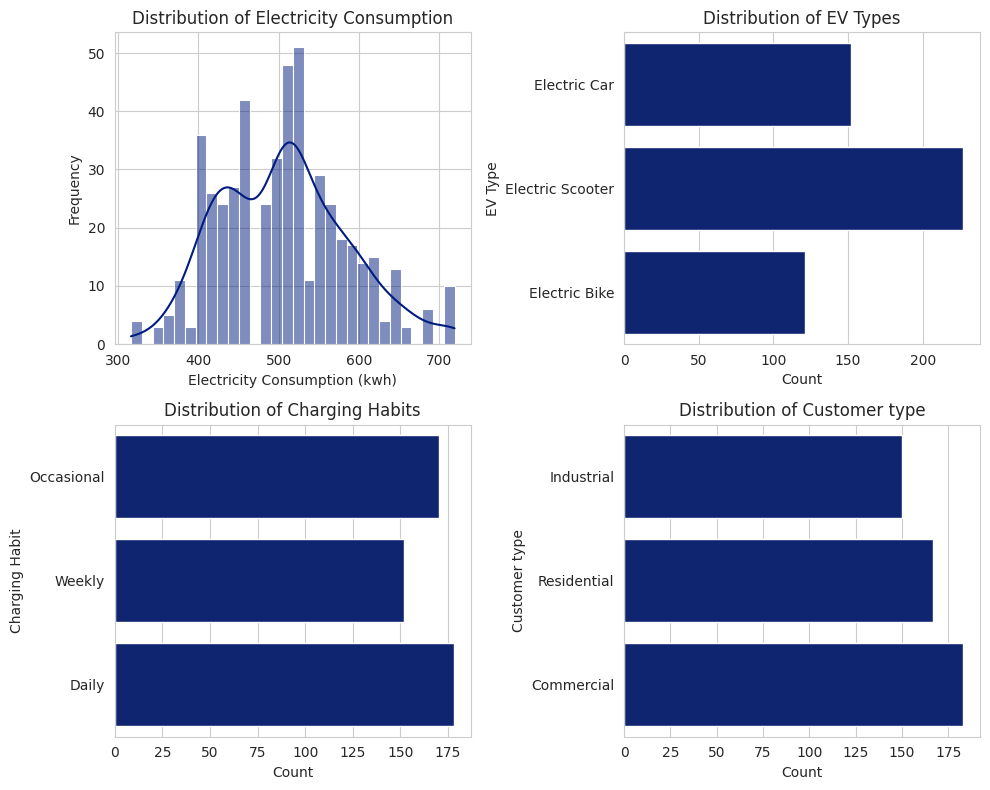

In [ ]:
# first step: setting the style and color palette of the plots
sns.set_style('whitegrid')
sns.set_palette('dark')

#create a 2x2 subplt grid
fig, ax = plt.subplots(2,2, figsize=(10,8))

#plotting the distribution of electricity consumption
sns.histplot(data=distribution_data, x='Electricity_Consumption (kWh)', bins=30, kde=True, ax=ax[0,0])
ax[0,0].set_title('Distribution of Electricity Consumption')
ax[0,0].set_xlabel('Electricity Consumption (kwh)')
ax[0,0].set_ylabel('Frequency')

#plotting the distribution of EV types
sns.countplot(data=distribution_data, y='EV_Type', ax=ax[0,1])
ax[0,1].set_title('Distribution of EV Types')
ax[0,1].set_xlabel('Count')
ax[0,1].set_ylabel('EV Type')

#plotting the distribution of charging habits
sns.countplot(data=distribution_data, y='Charging_Habit', ax=ax[1,0])
ax[1,0].set_title('Distribution of Charging Habits')
ax[1,0].set_xlabel('Count')
ax[1,0].set_ylabel('Charging Habit')

#plotting the distribution of charging habits
sns.countplot(data=distribution_data, y='Customer_Type', ax=ax[1,1])
ax[1,1].set_title('Distribution of Customer type')
ax[1,1].set_xlabel('Count')
ax[1,1].set_ylabel('Customer type')


#Adjusting layout
plt.tight_layout()

#Show the plots
plt.show()


### **INSIGHTS**

1. The distribution of electricity consumption is mostly around 500kWh
2. The distribution of Electric vehicle types showcased that the Electric scooter is the most commonly ued Electric vehicle type followed by electric car and then electric bike.
3. The distribution of charging habits shows that most of the users charge on a daily basis, followed by those who charge occassionally and then those who charge weekly
4. The most common customer type are those of the commercial sectors, followed by presidential and then industrial sector










## **BIVARIATE ANALYSIS**

In [ ]:
# Extract lattitude and longtitude for electronic vehicle charging station

distribution_data['ev_latitude']= distribution_data['EV_Charging_Station_Location'].apply(lambda x: float(x.split(',')[0].replace("(","").strip()))
distribution_data['ev_longitude']= distribution_data['EV_Charging_Station_Location'].apply(lambda x: float(x.split(',')[1].replace(")","").strip()))


# Extract lattitude and longtitude for substation location

geospatial_data['substation_latitude']= geospatial_data['Substation_Location'].apply(lambda x: float(x.split(',')[0].replace("(","").strip()))
geospatial_data['substation_longitude']= geospatial_data['Substation_Location'].apply(lambda x: float(x.split(',')[1].replace(")","").strip()))

#dropping the original location column to clean up the dataframe

distribution_data=distribution_data.drop(columns=['EV_Charging_Station_Location'])
geospatial_data=geospatial_data.drop(columns=['Substation_Location'])

In [ ]:
distribution_data.head()

,Timestamp,Geographical_Area,Customer_Type,Electricity_Consumption (kWh),EV_Charging_Station_Specifications,EV_Type,Charging_Habit,Number_of_EVs,Substation_ID,ev_latitude,ev_longitude
0,2020-01-10 18:00:00,Urban,Industrial,714.394409,Type 2,Electric Car,Occasional,8,Substation_907,64.019436,-129.531964
1,2020-01-22 17:00:00,Rural,Residential,554.336019,Type 2,Electric Scooter,Weekly,5,Substation_907,48.447827,-71.988591
2,2020-01-10 18:00:00,Urban,Industrial,714.394409,Type 2,Electric Car,Occasional,8,Substation_907,64.019436,-129.531964
3,2020-01-22 17:00:00,Rural,Residential,554.336019,Type 2,Electric Scooter,Weekly,5,Substation_907,48.447827,-71.988591
4,2020-01-10 18:00:00,Urban,Industrial,714.394409,Type 2,Electric Car,Occasional,8,Substation_907,64.019436,-129.531964


In [ ]:
geospatial_data.head()

,Substation_ID,Transmission_Line_Capacity (MW),substation_latitude,substation_longitude
0,Substation_907,40,57.258136,-70.905820
1,Substation_218,71,70.025385,-84.380572
2,Substation_339,85,80.393235,-75.797841
3,Substation_773,10,49.123078,-87.359890
4,Substation_349,40,66.798871,-86.511241


## **PLOTTING OF GRAPH**

<ipython-input-14-ba0aa01830e0>:8: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world=gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


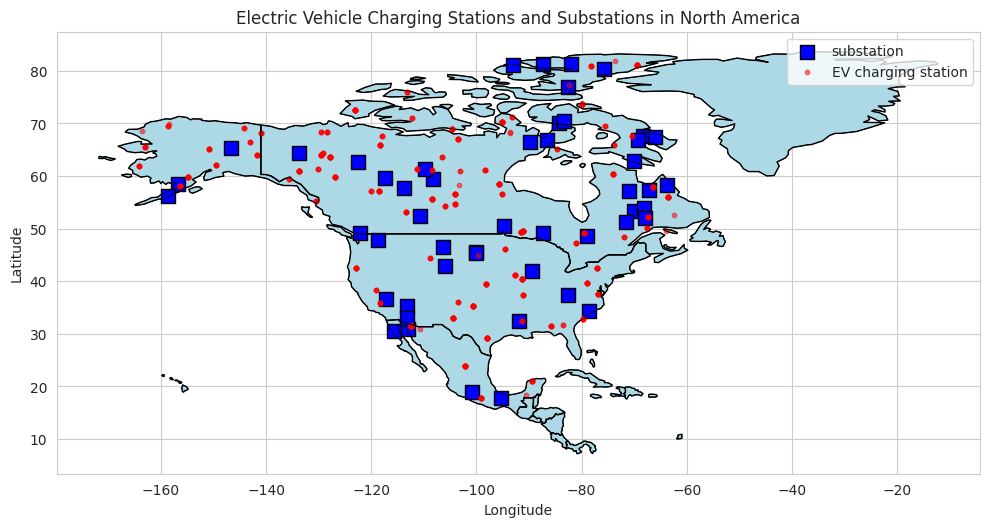

In [ ]:
# Converting the dataframe to geodataframes
ev_gdf=gpd.GeoDataFrame(distribution_data,
                        geometry=gpd.points_from_xy(distribution_data.ev_longitude, distribution_data.ev_latitude))
substation_gdf=gpd.GeoDataFrame(geospatial_data,
                        geometry=gpd.points_from_xy(geospatial_data.substation_longitude, geospatial_data.substation_latitude))

#Loading the world map
world=gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

#filtering to North America
north_america = world[world['continent']=='North America']

#Plotting the map for north america
fig, ax=plt.subplots(1, figsize=(10,8))
north_america.boundary.plot(ax=ax, linewidth= 0.5, color='black')
north_america.plot(ax=ax, color='lightblue', edgecolor= 'black')

#plotting the substation on the map
substation_gdf.plot(ax=ax, marker= 's', markersize=100, color='blue', edgecolor='black', label='substation')

#plotting ev charging stations on the map
ev_gdf.plot(ax=ax, markersize=10, color='red', label='EV charging station', alpha=0.5)

#setting title and axis labels
plt.title('Electric Vehicle Charging Stations and Substations in North America')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
#Connecting the EV charging station connected to substation, by importing lineString
from shapely.geometry import LineString

<ipython-input-16-bbce1306e30c>:18: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world=gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


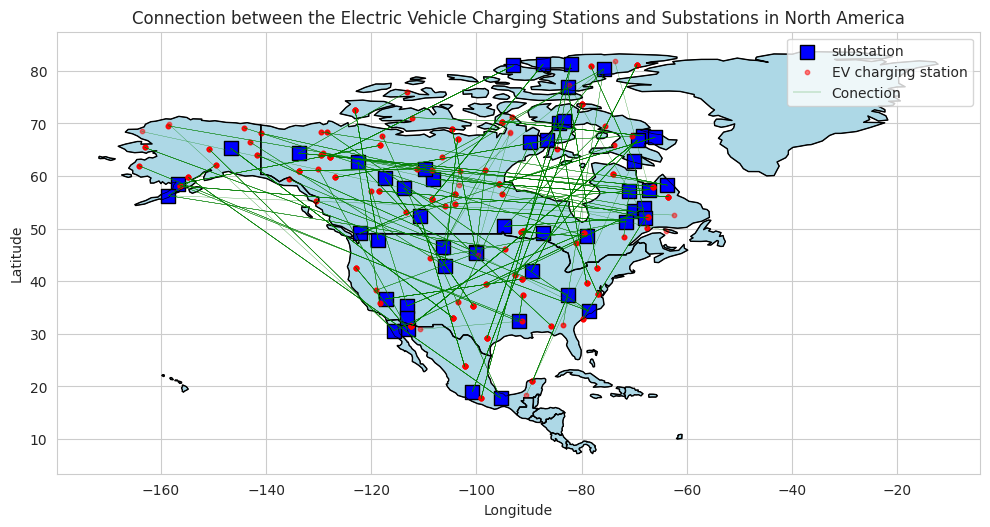

In [ ]:
# Converting the dataframe to geodataframes
ev_gdf=gpd.GeoDataFrame(distribution_data,
                        geometry=gpd.points_from_xy(distribution_data.ev_longitude, distribution_data.ev_latitude))
substation_gdf=gpd.GeoDataFrame(geospatial_data,
                        geometry=gpd.points_from_xy(geospatial_data.substation_longitude, geospatial_data.substation_latitude))

#creating a lines connectin each substation to it's associated ev charging station
lines= []
#merging the cordinate for the geospatial data with the distribution data, using common column, which is the substation ID. This is going to be a generic or a normal data frame, then we have to covert the datafame to a geodataframe in order to plot over the map
for _, ev_row in distribution_data.iterrows():
  substation=geospatial_data[geospatial_data['Substation_ID']==ev_row['Substation_ID']].iloc[0]
  line=[(ev_row['ev_longitude'], ev_row['ev_latitude']),
        (substation['substation_longitude'], substation['substation_latitude'])]
  lines.append(line)
line_gdf=gpd.GeoDataFrame(geometry=[LineString(line) for line in lines])

#Loading the world map
world=gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

#filtering to North America
north_america = world[world['continent']=='North America']

#Plotting the map for north america
fig, ax=plt.subplots(1, figsize=(10,7))
north_america.boundary.plot(ax=ax, linewidth= 0.5, color='black')
north_america.plot(ax=ax, color='lightblue', edgecolor= 'black')

#plotting the substation on the map
substation_gdf.plot(ax=ax, marker= 's', markersize=100, color='blue', edgecolor='black', label='substation')

#plotting ev charging stations on the map
ev_gdf.plot(ax=ax, markersize=10, color='red', label='EV charging station', alpha=0.5)

#plotting line
line_gdf.plot(ax=ax, linewidth=0.2, color='green', label='Conection')
#setting title and axis labels
plt.title('Connection between the Electric Vehicle Charging Stations and Substations in North America')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()




<ipython-input-17-af3283d767f2>:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


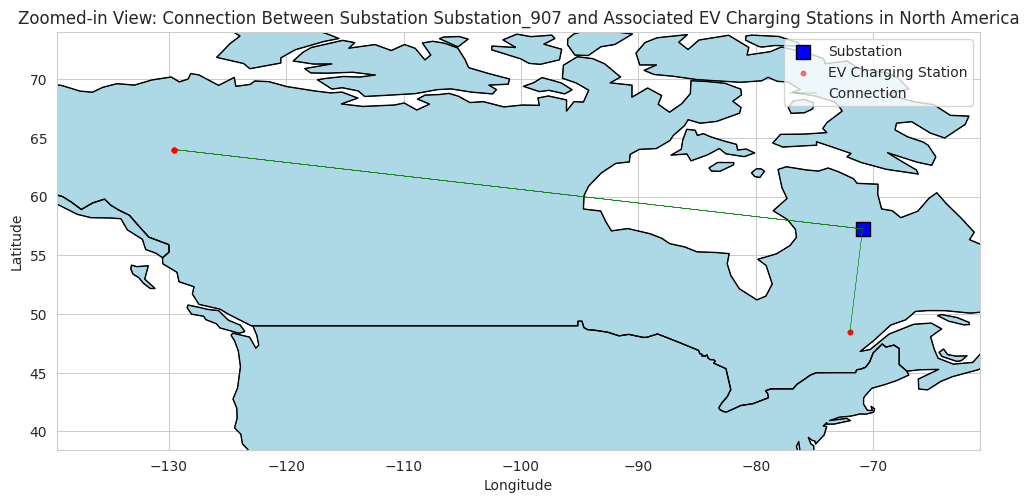

In [ ]:
# Zooming in to the first substation connection on our data to its EV charging station

# Filter for the first substation
selected_substation = geospatial_data.iloc[0]
associated_ev = distribution_data[distribution_data['Substation_ID'] == selected_substation['Substation_ID']]

# Convert to GeoDataFrame for EV charging stations
ev_gdf_selected = gpd.GeoDataFrame(
    associated_ev,
    geometry=gpd.points_from_xy(associated_ev['ev_longitude'], associated_ev['ev_latitude'])
)

# Convert the selected substation to a GeoDataFrame
substation_geometry = gpd.points_from_xy([selected_substation['substation_longitude']], [selected_substation['substation_latitude']])
substation_gdf_selected = gpd.GeoDataFrame(
    selected_substation.to_frame().transpose(),
    geometry=substation_geometry
)

# Creating lines for the selected substation
lines_selected = [
    (
        ev_row['ev_longitude'],
        ev_row['ev_latitude'],
        selected_substation['substation_longitude'],
        selected_substation['substation_latitude']
    )
    for _, ev_row in associated_ev.iterrows()
]
line_gdf_selected = gpd.GeoDataFrame(
    geometry=[LineString([(line[0], line[1]), (line[2], line[3])]) for line in lines_selected]
)

# Loading the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filtering to North America
north_america = world[world['continent'] == 'North America']

# Determining the bounding box for the zoomed area
buffer = 10  # degrees
minx, miny, maxx, maxy = line_gdf_selected.total_bounds
xlim = (minx - buffer, maxx + buffer)
ylim = (miny - buffer, maxy + buffer)

# Plotting the map for North America
fig, ax = plt.subplots(1, figsize=(10, 8))
north_america.boundary.plot(ax=ax, linewidth=0.5, color='black')
north_america.plot(ax=ax, color='lightblue', edgecolor='black')

# Plotting the substation on the map
substation_gdf_selected.plot(ax=ax, marker='s', markersize=100, color='blue', edgecolor='black', label='Substation')

# Plotting EV charging stations on the map
ev_gdf_selected.plot(ax=ax, markersize=10, color='red', label='EV Charging Station', alpha=0.5)

# Setting the zoom-in limit
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Plotting lines
line_gdf_selected.plot(ax=ax, linewidth=0.2, color='green', label='Connection')

# Setting title and axis labels
plt.title(f"Zoomed-in View: Connection Between Substation {selected_substation['Substation_ID']} and Associated EV Charging Stations in North America")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()


<ipython-input-18-87861298fc4c>:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


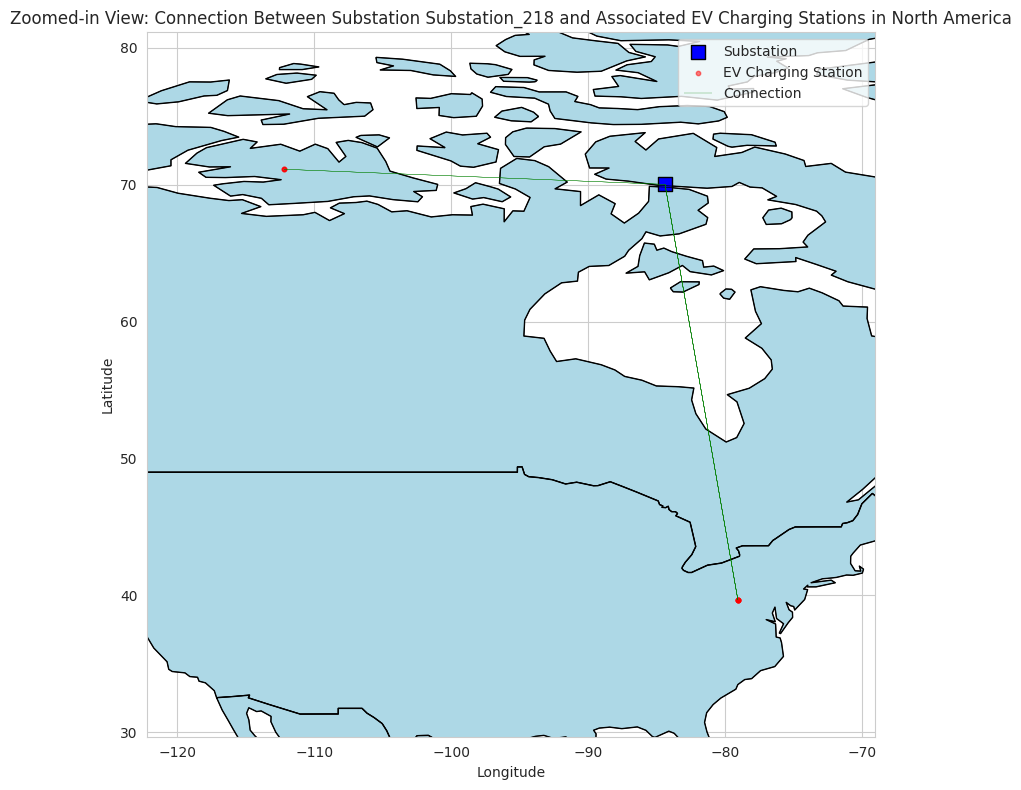

In [ ]:
# Zooming in to the first substation connection on our data to its EV charging station

# Filter for the first substation
selected_substation = geospatial_data.iloc[1]
associated_ev = distribution_data[distribution_data['Substation_ID'] == selected_substation['Substation_ID']]

# Convert to GeoDataFrame for EV charging stations
ev_gdf_selected = gpd.GeoDataFrame(
    associated_ev,
    geometry=gpd.points_from_xy(associated_ev['ev_longitude'], associated_ev['ev_latitude'])
)

# Convert the selected substation to a GeoDataFrame
substation_geometry = gpd.points_from_xy([selected_substation['substation_longitude']], [selected_substation['substation_latitude']])
substation_gdf_selected = gpd.GeoDataFrame(
    selected_substation.to_frame().transpose(),
    geometry=substation_geometry
)

# Creating lines for the selected substation
lines_selected = [
    (
        ev_row['ev_longitude'],
        ev_row['ev_latitude'],
        selected_substation['substation_longitude'],
        selected_substation['substation_latitude']
    )
    for _, ev_row in associated_ev.iterrows()
]
line_gdf_selected = gpd.GeoDataFrame(
    geometry=[LineString([(line[0], line[1]), (line[2], line[3])]) for line in lines_selected]
)

# Loading the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filtering to North America
north_america = world[world['continent'] == 'North America']

# Determining the bounding box for the zoomed area
buffer = 10  # degrees
minx, miny, maxx, maxy = line_gdf_selected.total_bounds
xlim = (minx - buffer, maxx + buffer)
ylim = (miny - buffer, maxy + buffer)

# Plotting the map for North America
fig, ax = plt.subplots(1, figsize=(10, 8))
north_america.boundary.plot(ax=ax, linewidth=0.5, color='black')
north_america.plot(ax=ax, color='lightblue', edgecolor='black')

# Plotting the substation on the map
substation_gdf_selected.plot(ax=ax, marker='s', markersize=100, color='blue', edgecolor='black', label='Substation')

# Plotting EV charging stations on the map
ev_gdf_selected.plot(ax=ax, markersize=10, color='red', label='EV Charging Station', alpha=0.5)

# Setting the zoom-in limit
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Plotting lines
line_gdf_selected.plot(ax=ax, linewidth=0.2, color='green', label='Connection')

# Setting title and axis labels
plt.title(f"Zoomed-in View: Connection Between Substation {selected_substation['Substation_ID']} and Associated EV Charging Stations in North America")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()


<ipython-input-19-265243ef7f4b>:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


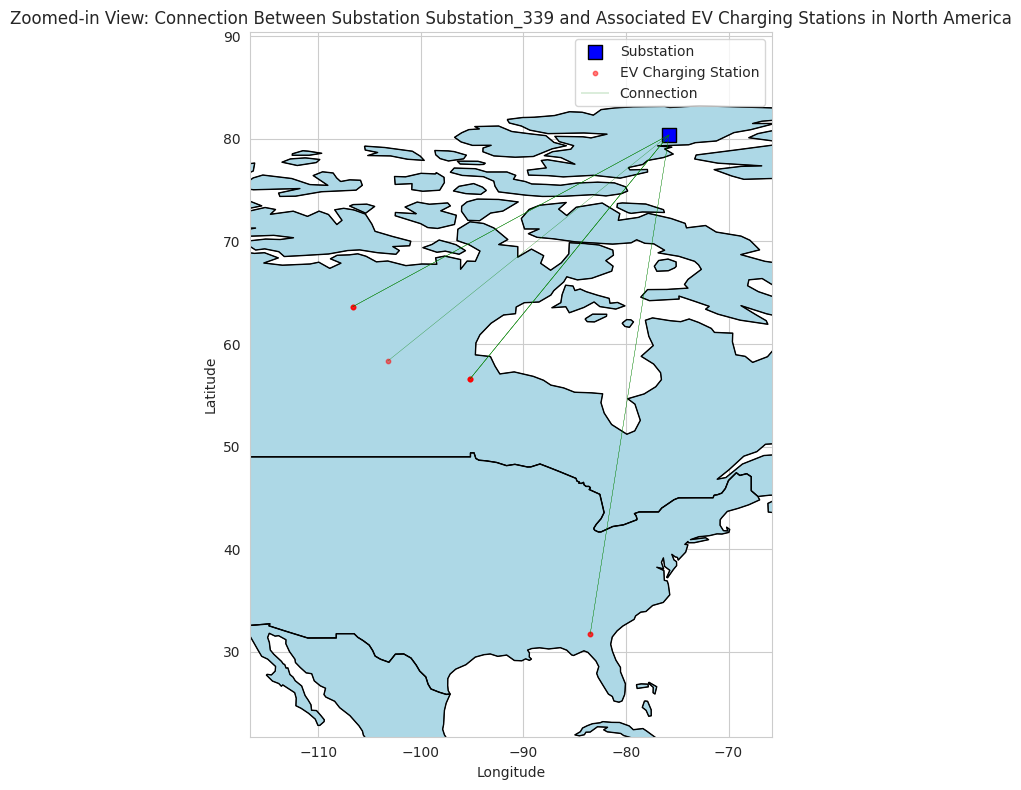

In [ ]:
# Zooming in to the first substation connection on our data to its EV charging station

# Filter for the first substation
selected_substation = geospatial_data.iloc[2]
associated_ev = distribution_data[distribution_data['Substation_ID'] == selected_substation['Substation_ID']]

# Convert to GeoDataFrame for EV charging stations
ev_gdf_selected = gpd.GeoDataFrame(
    associated_ev,
    geometry=gpd.points_from_xy(associated_ev['ev_longitude'], associated_ev['ev_latitude'])
)

# Convert the selected substation to a GeoDataFrame
substation_geometry = gpd.points_from_xy([selected_substation['substation_longitude']], [selected_substation['substation_latitude']])
substation_gdf_selected = gpd.GeoDataFrame(
    selected_substation.to_frame().transpose(),
    geometry=substation_geometry
)

# Creating lines for the selected substation
lines_selected = [
    (
        ev_row['ev_longitude'],
        ev_row['ev_latitude'],
        selected_substation['substation_longitude'],
        selected_substation['substation_latitude']
    )
    for _, ev_row in associated_ev.iterrows()
]
line_gdf_selected = gpd.GeoDataFrame(
    geometry=[LineString([(line[0], line[1]), (line[2], line[3])]) for line in lines_selected]
)

# Loading the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filtering to North America
north_america = world[world['continent'] == 'North America']

# Determining the bounding box for the zoomed area
buffer = 10  # degrees
minx, miny, maxx, maxy = line_gdf_selected.total_bounds
xlim = (minx - buffer, maxx + buffer)
ylim = (miny - buffer, maxy + buffer)

# Plotting the map for North America
fig, ax = plt.subplots(1, figsize=(10, 8))
north_america.boundary.plot(ax=ax, linewidth=0.5, color='black')
north_america.plot(ax=ax, color='lightblue', edgecolor='black')

# Plotting the substation on the map
substation_gdf_selected.plot(ax=ax, marker='s', markersize=100, color='blue', edgecolor='black', label='Substation')

# Plotting EV charging stations on the map
ev_gdf_selected.plot(ax=ax, markersize=10, color='red', label='EV Charging Station', alpha=0.5)

# Setting the zoom-in limit
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Plotting lines
line_gdf_selected.plot(ax=ax, linewidth=0.2, color='green', label='Connection')

# Setting title and axis labels
plt.title(f"Zoomed-in View: Connection Between Substation {selected_substation['Substation_ID']} and Associated EV Charging Stations in North America")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()


<ipython-input-20-b66f95252844>:35: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


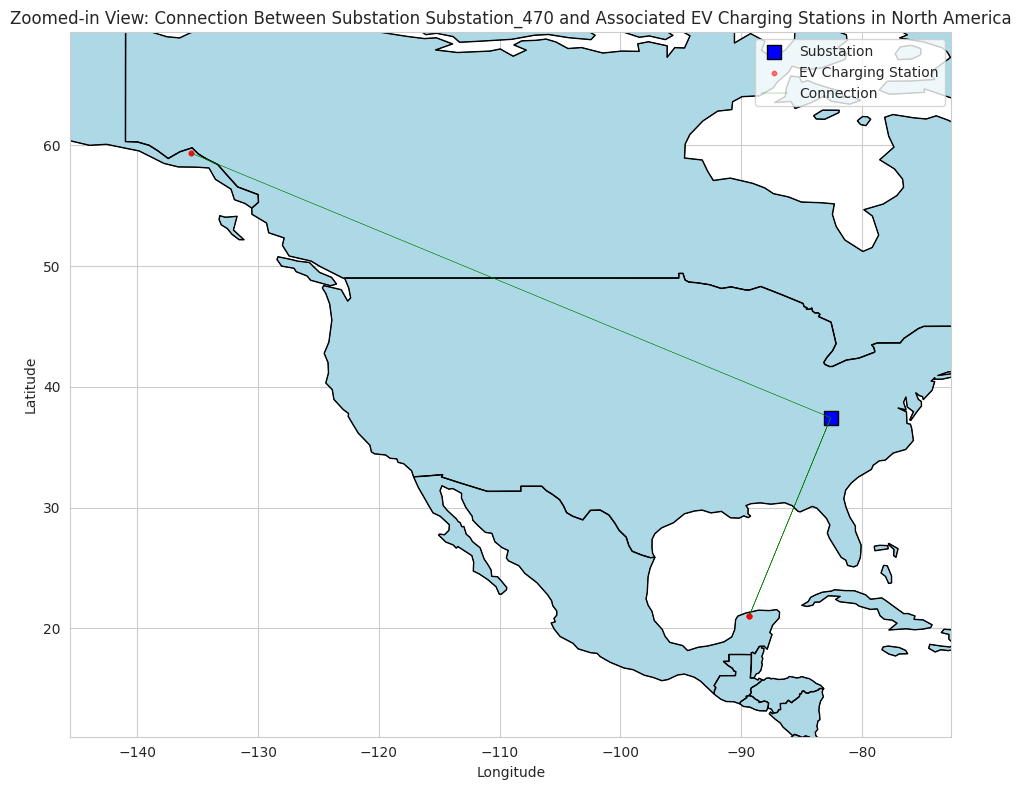

In [ ]:
# Zooming in to the first substation connection on our data to its EV charging station

# Filter for the first substation
selected_substation = geospatial_data.iloc[49]
associated_ev = distribution_data[distribution_data['Substation_ID'] == selected_substation['Substation_ID']]

# Convert to GeoDataFrame for EV charging stations
ev_gdf_selected = gpd.GeoDataFrame(
    associated_ev,
    geometry=gpd.points_from_xy(associated_ev['ev_longitude'], associated_ev['ev_latitude'])
)

# Convert the selected substation to a GeoDataFrame
substation_geometry = gpd.points_from_xy([selected_substation['substation_longitude']], [selected_substation['substation_latitude']])
substation_gdf_selected = gpd.GeoDataFrame(
    selected_substation.to_frame().transpose(),
    geometry=substation_geometry
)

# Creating lines for the selected substation
lines_selected = [
    (
        ev_row['ev_longitude'],
        ev_row['ev_latitude'],
        selected_substation['substation_longitude'],
        selected_substation['substation_latitude']
    )
    for _, ev_row in associated_ev.iterrows()
]
line_gdf_selected = gpd.GeoDataFrame(
    geometry=[LineString([(line[0], line[1]), (line[2], line[3])]) for line in lines_selected]
)

# Loading the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filtering to North America
north_america = world[world['continent'] == 'North America']

# Determining the bounding box for the zoomed area
buffer = 10  # degrees
minx, miny, maxx, maxy = line_gdf_selected.total_bounds
xlim = (minx - buffer, maxx + buffer)
ylim = (miny - buffer, maxy + buffer)

# Plotting the map for North America
fig, ax = plt.subplots(1, figsize=(10, 8))
north_america.boundary.plot(ax=ax, linewidth=0.5, color='black')
north_america.plot(ax=ax, color='lightblue', edgecolor='black')

# Plotting the substation on the map
substation_gdf_selected.plot(ax=ax, marker='s', markersize=100, color='blue', edgecolor='black', label='Substation')

# Plotting EV charging stations on the map
ev_gdf_selected.plot(ax=ax, markersize=10, color='red', label='EV Charging Station', alpha=0.5)

# Setting the zoom-in limit
ax.set_xlim(xlim)
ax.set_ylim(ylim)

# Plotting lines
line_gdf_selected.plot(ax=ax, linewidth=0.2, color='green', label='Connection')

# Setting title and axis labels
plt.title(f"Zoomed-in View: Connection Between Substation {selected_substation['Substation_ID']} and Associated EV Charging Stations in North America")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()


## Further ivnvestigations


<ipython-input-21-9023fb442b24>:11: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


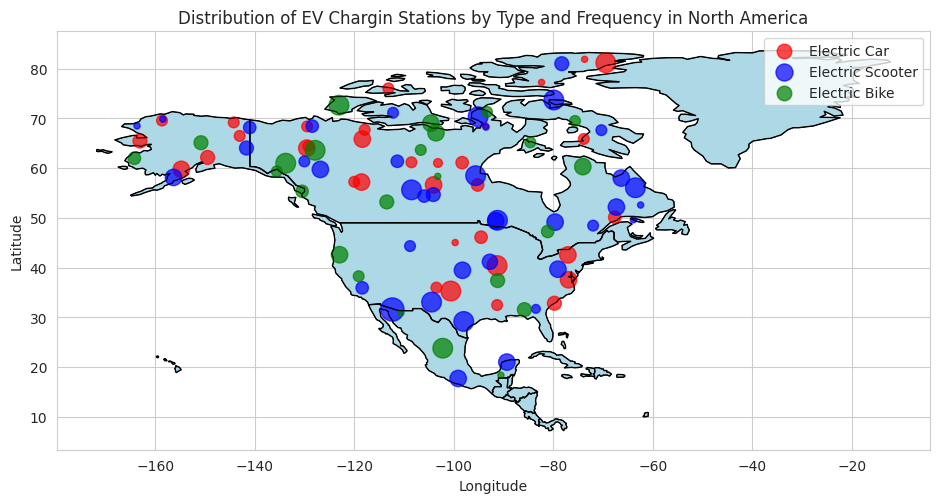

In [ ]:
#grouping by location and the ev type, then counting the number of stations
grouped_data = distribution_data.groupby(['ev_latitude', 'ev_longitude', 'EV_Type']).size().reset_index(name='count')

#converting grouped data into a geodataframe

grouped_gdf = gpd.GeoDataFrame(grouped_data,
                               geometry=gpd.points_from_xy(grouped_data.ev_longitude, grouped_data.ev_latitude))

#loading the world map data and filter for north america
# Loading the world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Filtering to North America
north_america = world[world['continent'] == 'North America']

# Plotting the map for North America
fig, ax = plt.subplots(1, figsize=(10, 5))
north_america.boundary.plot(ax=ax, linewidth=0.5, color='black')
north_america.plot(ax=ax, color='lightblue', edgecolor='black')

#defining color for each of the ev types
colors = {"Electric Car": "red", "Electric Scooter": "blue", "Electric Bike": "green" }

#plotting ev type
for ev_type, color in colors.items():
  sub_gdf = grouped_gdf[grouped_gdf["EV_Type"] == ev_type]
  sub_gdf.plot(ax=ax, markersize = sub_gdf["count"]* 20, color = color, label = ev_type, alpha=0.7)

# Setting title and axis labels
plt.title(f"Distribution of EV Chargin Stations by Type and Frequency in North America")
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.tight_layout()
plt.show()




## **NETWORK CAPACITY ASSESSMENT**
To perform network capacity assessment

1.   Calculate the total electricity consumption for eachsubstation
2.   Compare the total electricity consumption with the transmissin line capacity



In [ ]:
# Grouping the EV distribution data by Substation ID and calculating the total electricity consumption for each substation
total_consumption_per_substation = distribution_data.groupby('Substation_ID')['Electricity_Consumption (kWh)'].sum().reset_index()

# Merging the total consumption data with geospatial data
network_capacity_data = pd.merge(geospatial_data, total_consumption_per_substation, on='Substation_ID')

# Renaming the columns for better understanding
network_capacity_data.rename(columns={'Electricity_Consumption (kWh)': 'Total_Consumption (kWh)'}, inplace=True)

# Calculating the ratio of total consumption to transmission line capacity
# Conversion: 1 MW = 1000 kWh
network_capacity_data['Consumption_to_Capacity_Ratio'] = network_capacity_data['Total_Consumption (kWh)'] / \
    (network_capacity_data['Transmission_Line_Capacity (MW)'] * 1000)


In [ ]:
network_capacity_data.head()

,Substation_ID,Transmission_Line_Capacity (MW),substation_latitude,substation_longitude,Total_Consumption (kWh),Consumption_to_Capacity_Ratio
0,Substation_907,40,57.258136,-70.905820,6663.768920,0.166594
1,Substation_218,71,70.025385,-84.380572,5997.437051,0.084471
2,Substation_339,85,80.393235,-75.797841,4536.778685,0.053374
3,Substation_773,10,49.123078,-87.359890,4426.337993,0.442634
4,Substation_349,40,66.798871,-86.511241,4901.836555,0.122546


In [ ]:
from shapely.geometry import Point

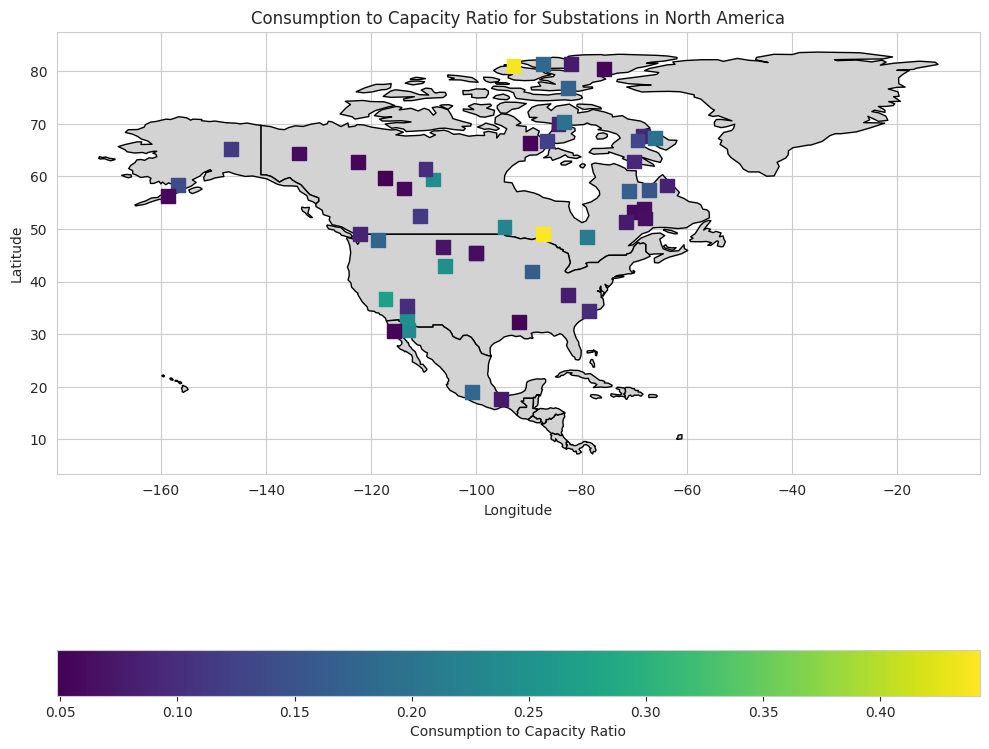

In [ ]:
#creating the GeoDataFrame for the network capacity for the dataframes
geometry_network_capacity = [Point(lon, lat) for lon, lat in zip (network_capacity_data['substation_longitude'], network_capacity_data['substation_latitude'])]
gdf_network_capacity = gpd.GeoDataFrame(network_capacity_data, geometry=geometry_network_capacity)

#plotting in choropleth style
fig, ax = plt.subplots(figsize=(10, 12))
north_america.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf_network_capacity.plot(column='Consumption_to_Capacity_Ratio', cmap='viridis',  marker='s', markersize= 100,ax=ax, legend=True, legend_kwds={'label': 'Consumption to Capacity Ratio','orientation':"horizontal"})

ax.set_title("Consumption to Capacity Ratio for Substations in North America")
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

In [ ]:
#grouping by the substation_id for the number of evs
ev_counts= distribution_data.groupby('Substation_ID')['Number_of_EVs'].sum().reset_index()

#merging with network capacity data with ev counts
final_data= pd.merge(ev_counts, network_capacity_data, on='Substation_ID')

#Correlation
correlation_ratio= final_data["Number_of_EVs"].corr(final_data['Consumption_to_Capacity_Ratio'])

In [ ]:
correlation_ratio

-0.10944923035990646

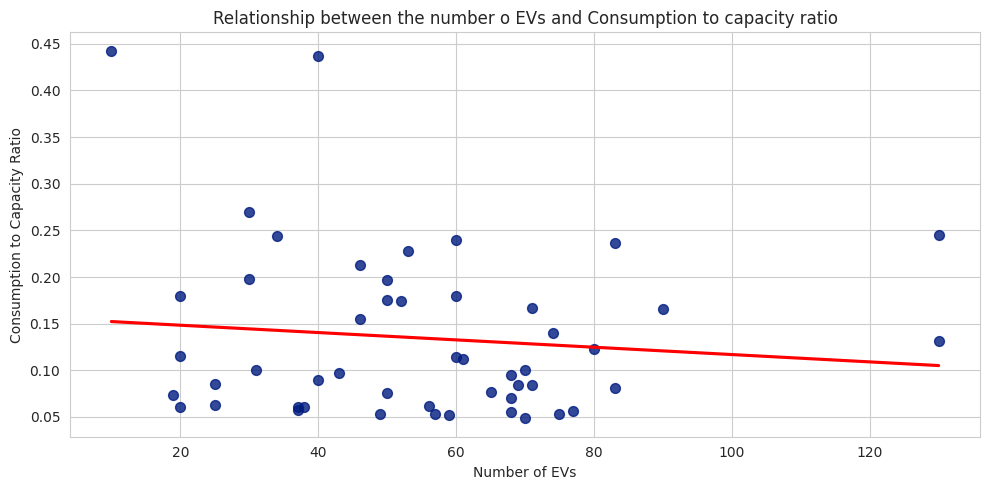

In [ ]:
#scattered plot with regression line
plt.figure(figsize=(10, 5))
sns.regplot(x='Number_of_EVs', y='Consumption_to_Capacity_Ratio', data=final_data, scatter_kws={'s':50}, line_kws={'color': 'red'}, ci=None)
plt.title('Relationship between the number o EVs and Consumption to capacity ratio')
plt.xlabel ('Number of EVs')
plt.ylabel('Consumption to Capacity Ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

## Identifying Bottlenecks
*  By analysing the map, we can identify the substations and areas that are potential bottlenecks in the distribution network. These are the areas where the consumption is high.



In [ ]:
#Filtering consumption to capacity greater than or equal to 0.9
bottleneck_substation = network_capacity_data[network_capacity_data['Consumption_to_Capacity_Ratio']>=0.9]

In [ ]:
bottleneck_substation

,Substation_ID,Transmission_Line_Capacity (MW),substation_latitude,substation_longitude,Total_Consumption (kWh),Consumption_to_Capacity_Ratio


**Insight**

The result shows that there is no station whwere the consumtpion to capacity ration is greater than one. Therefore, there is no bottleneck.

## **Optimizing Network Uprade**

For optimizing network uprades, the focus is on the substations with potential to have high consumption_upgradesto_capacity_ratio. Therefore, upgrading the transmission lines or adding additinal capacity in these areas can help in mitigating the potential of having increased load effectively and ensuring grid reliability.

**Additionally**
* The geographical distribution of EV charging stations, where EV charging stations are quite far from the Substation.

**Also, the business should look into:**
* Potential future growth in EV adoption in different areas
* Cost associated with different upgrade options






In [ ]:
# Looking at the top five substation with potentilal to reach the overload gap
top_5_substations = network_capacity_data.nlargest(5, 'Consumption_to_Capacity_Ratio')
top_5_substations

,Substation_ID,Transmission_Line_Capacity (MW),substation_latitude,substation_longitude,Total_Consumption (kWh),Consumption_to_Capacity_Ratio
3,Substation_773,10,49.123078,-87.359890,4426.337993,0.442634
14,Substation_87,12,81.031814,-92.941747,5243.800714,0.436983
27,Substation_711,17,36.618181,-117.277556,4579.354677,0.269374
20,Substation_11,43,33.082269,-113.118931,10534.827701,0.244996
42,Substation_258,22,42.952789,-106.049333,5378.214378,0.244464


**Insight**

These are the top stations with potential grid overload.

## **Correlation with the Weather Data**
* Analyzing the correlation between the weather data and electricity consumption can provide insights into how weather condition affects distribution



In [ ]:
#merging weather data with distribution data
merged_data= pd.merge(weather_data, distribution_data, on=['Timestamp','Substation_ID'])

#Calculating the correlation between the weather conditions and electricity consumption
correlation_matrix = merged_data[['Temperature (°C)', 'Precipitation (mm)', 'Electricity_Consumption (kWh)']].corr()

#Displaying
correlation_matrix

,Temperature (°C),Precipitation (mm),Electricity_Consumption (kWh)
Temperature (°C),1.000000,-0.005828,0.131543
Precipitation (mm),-0.005828,1.000000,0.085014
Electricity_Consumption (kWh),0.131543,0.085014,1.000000


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

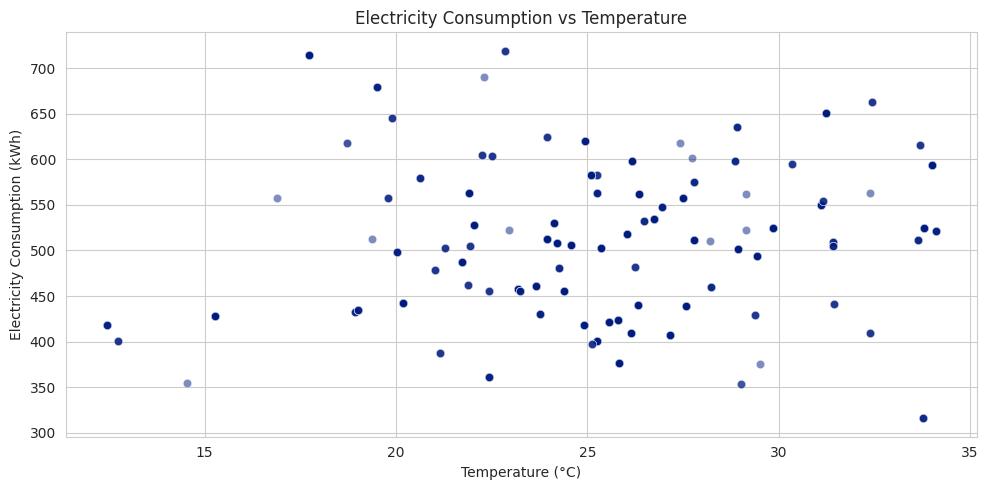

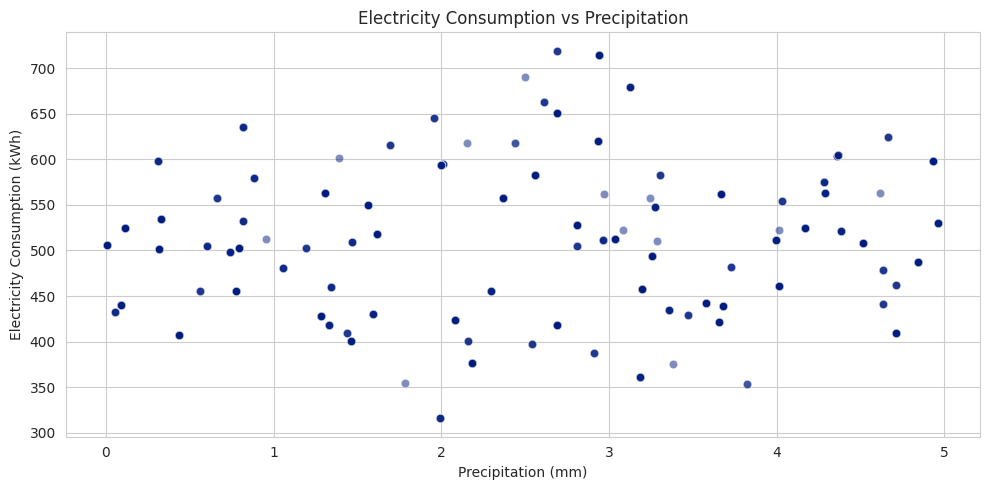

In [ ]:
#Visualizing the relationship for better undergtanding
#Electricity consumption vs temperature

plt.figure(figsize=(10, 5))
sns.scatterplot(x='Temperature (°C)', y='Electricity_Consumption (kWh)', data=merged_data, alpha=0.5)
plt.title('Electricity Consumption vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Electricity Consumption (kWh)')
plt.grid(True)
plt.tight_layout()
plt

#Visualizing the relationship for better undergtanding
#Electricity consumption vs precipitation

plt.figure(figsize=(10, 5))
sns.scatterplot(x='Precipitation (mm)', y='Electricity_Consumption (kWh)', data=merged_data, alpha=0.5)
plt.title('Electricity Consumption vs Precipitation')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Electricity Consumption (kWh)')
plt.grid(True)
plt.tight_layout()
plt

The is no significant correlation between Electricity consumption, precipitation and temperature as the scatterplot doesnt have a pattern to deduce any form of correlation

## **Insight and Recommendations**
1. **Electricity Consumption**: The electricity consumption is mostly centered around 500 kWh, with certain instances of higher consumption. This indicates varied demand at different times and locations.

2. **EV Types and Charing Habits**: Electric scooters are the most common types of EVs, Most customers charge their EVs daily indicating a considered daily load on the distribution network.

3. **Consumer type**: Most consumers are commercial consumers

4. **Geospatial Distribution I:** The spatial distribution of substations and the EV charging stations is widespread.

5. **Geospatial Distribution II:** The EV charging stations seem to be far from it's corresponding substations.

6. **Network Capacity**: Some substations have a high Consumpton_o_Capacity_Ratio. Indicating potential bottlenecks and overloads in the network. There is also no correlation with the number of EVs per substation and the Consumption to Capacity Ratio, this shows that the Number of EVs is not a factor for overload.

7. **Weather Correlation**: The correlation between weather conditions (temperature and precipitation) and electricity consumption is weak in the current dataset. Suggesting that other factors might be more influential in affecting electricity consumption



## **The Optimization Strategy/Recommendation**

This is based on the analysis done and the business problem at hand, all these should be incorperated into the business

1.  **Priortize Substation Upgrade**: Prioritize upgrades at substations where the Consumer_to_capacity_ratio is high, which indicates potential overloads. Upgrade the transmission lines because the EV charing station are too far from their corresponding substations

2.  **Geospatial Analysis for Upgrade Planning**: Use geospatial analysis to determine the optimal locations for new substations or upgrades to existing ones. Consider factors like the proximity to high load demand areas (areas with high consumption to capacity ratio) and geographical constraints.

3. **Demand Side Management**: Implement demand-side management strategies to balance the load on the grid. Encourage customers to charge their EVs during off-peak hours through incentives or dynamic pricing.

4. **Advanced Monitoring and Analytics**: Deploy advanced monitoring systems to monitor the health and performance of the distribution network continuously. Use analytics to predict potential issues and take preventive action.

5. **Cost-Benefit Analysis:** Conduct a comprehensive cost-benefit analysis for different upgrade options. Consider factors like the cost of upgrades, operational costs, potential revenue from increased capacity, and the impact on service reliability and customer satistfaction.

6. **Customer Engagement:** Engage with customers to understand their needs and expectation. Provide clear communication about network upgrades and how they will enhance service reliability and meet the growing demand for EV charging.

7. **Continous improvement:** Continously monitor and assess the performance of the distribution network. ather feedback from customers and other stakeholders, and use this feedback to make further improvement and optimizations.

By following these steps, Powercharge utilities can develop an effective optimization strategy to manage the increased load demand from EV charging stations, which ensures the reliablity and resilience of the distribution network, and als meet the expectations of customers, all while optimizing costs and ensuring regulatory compliance
